# Model Experimentation & Validation

In this notebook, we move beyond basic Exploratory Data Analysis and dive into algorithmic experimentation. We will manually evaluate tree-based ensembles to generate **Feature Importance Matrices**, train a PyTorch **Artificial Neural Network (ANN)** to inspect validation loss curves, and evaluate classification errors via **Confusion Matrices and ROC Curves**.

This explains the *"Why"* behind our automated `model_trainer_ml.py` script.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.io import arff
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, roc_curve, auc
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

plt.style.use('ggplot')

### 1. Data Preparation
We load the `.arff` dataset, map the target classes, and perform a standard 80/20 split.

In [2]:
# Load Data
data_path = '../data/phishing_tabular_data/dataset.arff'
data, meta = arff.loadarff(data_path)
df = pd.DataFrame(data)

# Decode and map target
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].str.decode('utf-8').astype(int)
df['Result'] = df['Result'].map({-1: 1, 1: 0})

X = df.drop(columns=['Result'])
y = df['Result']
feature_names = X.columns

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Training instances: {X_train.shape[0]}, Testing instances: {X_test.shape[0]}")

Training instances: 8844, Testing instances: 2211


### 2. Feature Importance Matrix (XGBoost)
Why does XGBoost achieve ~97% accuracy? Let's extract its feature importance weights to see which structural indicators it prioritizes.

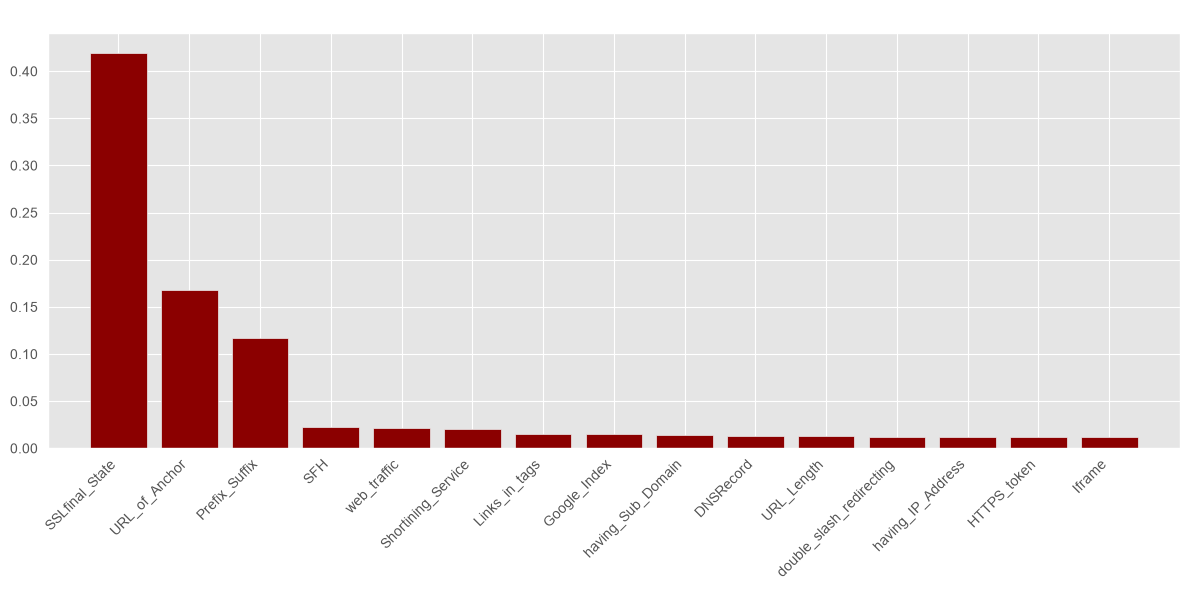

In [3]:
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_model.fit(X_train, y_train)

importances = xgb_model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(12, 6))
plt.title("XGBoost Feature Importance (Top 15)")
plt.bar(range(15), importances[indices][:15], align="center", color='darkred')
plt.xticks(range(15), [feature_names[i] for i in indices[:15]], rotation=45, ha="right")
plt.xlim([-1, 15])
plt.tight_layout()
plt.show()

### 3. PyTorch ANN Validation Curves
To ensure our Deep Learning engine is not overfitting the tabular data, we will train it for 50 epochs and plot the Training Loss vs. Validation Loss side-by-side.

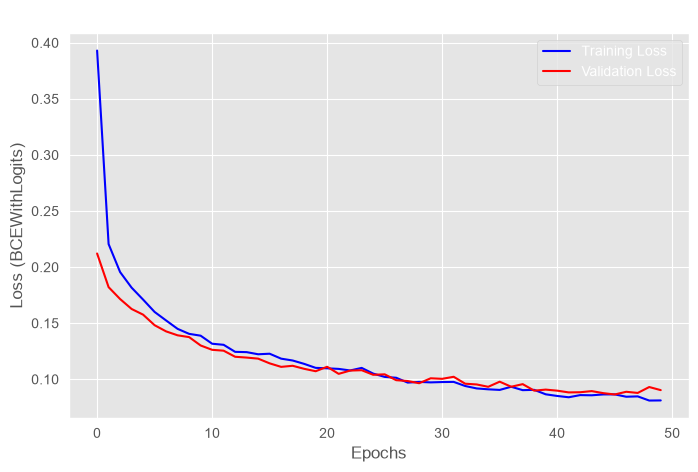

In [4]:
# Convert to Tensors
X_tr_t = torch.tensor(X_train.values, dtype=torch.float32)
y_tr_t = torch.tensor(y_train.values, dtype=torch.float32).unsqueeze(1)
X_te_t = torch.tensor(X_test.values, dtype=torch.float32)
y_te_t = torch.tensor(y_test.values, dtype=torch.float32).unsqueeze(1)

train_loader = DataLoader(TensorDataset(X_tr_t, y_tr_t), batch_size=64, shuffle=True)

# Define Model
class PhishingANN(nn.Module):
    def __init__(self, input_dim):
        super(PhishingANN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(64, 32), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(32, 1)
        )
    def forward(self, x): return self.net(x)

model = PhishingANN(X_train.shape[1])
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

train_losses, val_losses = [], []

# Training Loop
for epoch in range(50):
    model.train()
    batch_losses = []
    for bx, by in train_loader:
        optimizer.zero_grad()
        loss = criterion(model(bx), by)
        loss.backward()
        optimizer.step()
        batch_losses.append(loss.item())
    
    train_losses.append(np.mean(batch_losses))
    
    model.eval()
    with torch.no_grad():
        val_loss = criterion(model(X_te_t), y_te_t).item()
        val_losses.append(val_loss)

# Plot Curves
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label='Training Loss', color='blue')
plt.plot(val_losses, label='Validation Loss', color='red')
plt.title('PyTorch ANN: Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss (BCEWithLogits)')
plt.legend()
plt.show()

### 4. Classification Errors: Confusion Matrix & ROC Curve
Finally, we evaluate the XGBoost predictions structurally to see True Positives (correctly caught phishing sites) vs False Positives (legitimate sites incorrectly flagged).

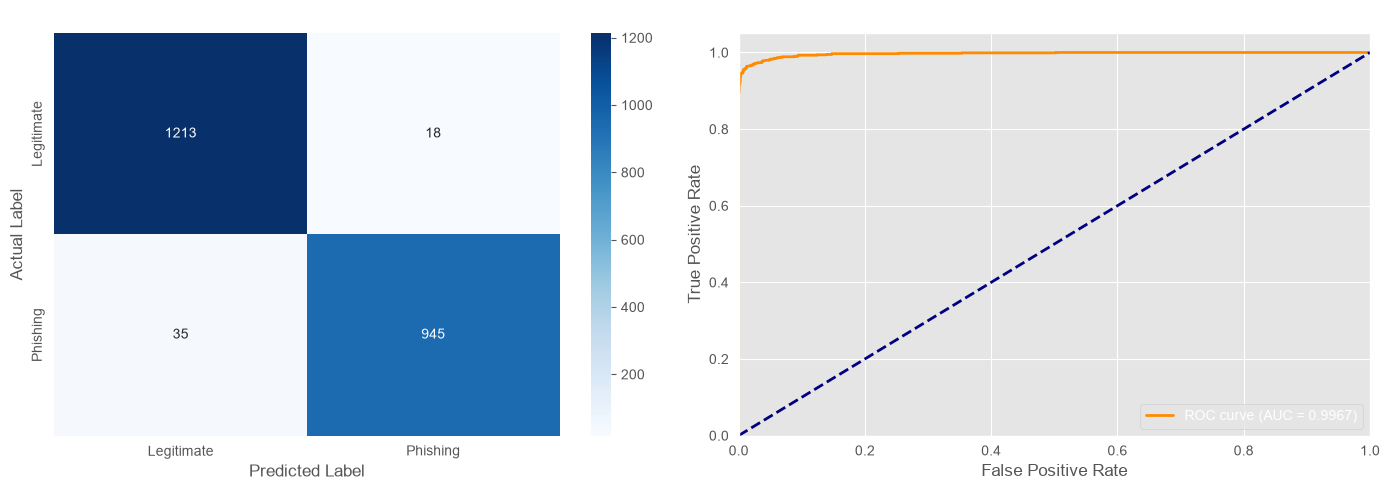

In [5]:
y_pred = xgb_model.predict(X_test)
y_prob = xgb_model.predict_proba(X_test)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0], 
            xticklabels=['Legitimate', 'Phishing'], yticklabels=['Legitimate', 'Phishing'])
axes[0].set_title('XGBoost Confusion Matrix')
axes[0].set_ylabel('Actual Label')
axes[0].set_xlabel('Predicted Label')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Receiver Operating Characteristic (ROC)')
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()